In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# Base dataset
df = pd.read_csv("../../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")

In [20]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [21]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [22]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [23]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [24]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [25]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [26]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [27]:
assert y.notna().all()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [30]:
# Subsample 50% of training set for grid search (KNN is slow on large datasets)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=100_000,
    stratify=y_train,
    random_state=42
)

print(f"Full training set:  {X_train.shape[0]:,} rows")
print(f"Subsample for grid: {X_train_sub.shape[0]:,} rows")

Full training set:  1,065,142 rows
Subsample for grid: 100,000 rows


In [31]:
knn = KNeighborsClassifier()

In [32]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", knn)
])

In [33]:
param_grid = {
    "model__n_neighbors": [5, 11, 21],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_sub, y_train_sub)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=uniform; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=distance; total time= 2.7min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 2.8min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 2.8min
[CV] END model__metric=euclidean, model__n_neighbors=5, model__weights=uniform; total time= 2.8min
[CV] END model__metric=euclidean, model__

/Users/skylarliu/Documents/GitHub/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.0min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=uniform; total time= 2.9min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.1min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=uniform; total time= 3.1min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.1min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=distance; total time= 2.9min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=distance; total time= 2.9min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=uniform; total time= 3.0min
[CV] END model__metric=euclidean, model__n_neighbors=11, model__weights=distance; total time= 3.1min
[CV] END model__metric=euclidean, model__n_neighbors=21, model__weights=uniform; total time= 3

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [5, 11, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [36]:
best_knn = grid.best_estimator_

y_test_pred = best_knn.predict(X_test)

print("Best KNN parameters:")
print(grid.best_params_)

print("\nKNN — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best KNN parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'}

KNN — Test Set Performance
              precision    recall  f1-score   support

       Small       0.92      0.70      0.79     34494
         Fit       0.90      0.98      0.94    174054
       Large       0.94      0.82      0.88     57738

    accuracy                           0.91    266286
   macro avg       0.92      0.83      0.87    266286
weighted avg       0.91      0.91      0.90    266286



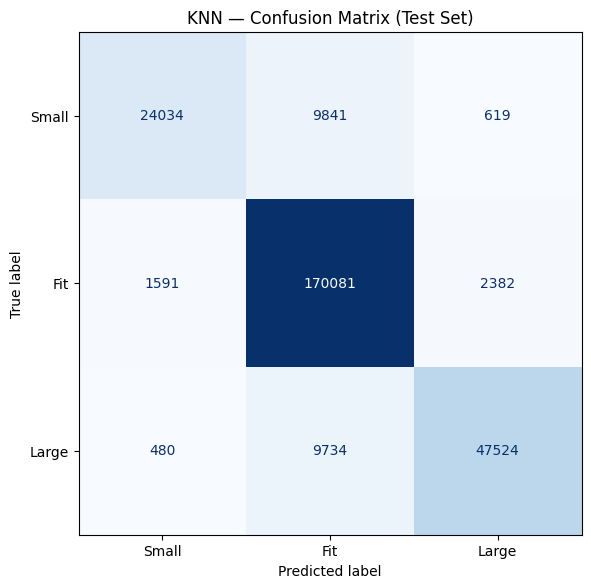

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("KNN — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/knn_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
knn_proba = best_knn.predict_proba(X_test)

knn_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": knn_proba[:, 0],
    "prob_fit": knn_proba[:, 1],
    "prob_large": knn_proba[:, 2]
})

knn_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/knn_fit_probabilities.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_knn,
    "../../Models/knn_fit_classifier.joblib"
)

['../Models/knn_fit_classifier.joblib']

In [ ]:
# After fitting
prep = best_knn.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/knn_feature_names.csv",
    index=False
)

# KNN Classifier Overview

### Overview
A K-Nearest Neighbors classifier was trained on a 100,000-row stratified subsample of the training set for hyperparameter tuning via grid search, then evaluated on the full test set of 266,286 samples. The optimal parameters were n_neighbors=21, weights="distance", and metric="manhattan".

### Overall Performance
The model achieved 91% accuracy with a weighted F1-score of 0.90 — the strongest overall performance of the models evaluated. The macro F1 of 0.87 also reflects solid balance across all three classes, a notable improvement over the tree-based ensemble methods.

### Class-Level Analysis
**Fit (Majority Class)**
Excellent performance with 0.90 precision and 0.98 recall (F1 = 0.94). KNN correctly identified 170,081 of 174,054 true Fit samples, with minimal leakage into other classes.

**Large**
Strong results with 0.94 precision and 0.82 recall (F1 = 0.88). Of 57,738 true Large samples, 47,524 were correctly classified. The main source of error is confusion with Fit (9,734 misclassified), which is consistent across all models given the overlapping feature distributions between these classes.

**Small (Minority Class)**
A meaningful improvement over the tree-based models. Precision is 0.92 (very few false positives), though recall drops to 0.70, meaning 10,460 true Small items were missed (mostly predicted as Fit). This precision-recall tradeoff reflects the distance-weighted approach: KNN is conservative about predicting Small, but when it does, it's usually right.

### Subsampling Note
Grid search was conducted on a stratified 100k-row subsample due to KNN's computational constraints at scale — distance computation grows linearly with training set size, making full-dataset CV impractical. The best parameters were then used to fit and predict as normal. This may slightly underestimate performance relative to tuning on the full training set.

### Key Takeaways
KNN delivers the best aggregate performance of the models compared, driven largely by its strong precision across all classes. Its weakness is Small recall, but unlike the bagging model, it avoids the false positive problem on Small predictions — a meaningful advantage in a consumer-facing recommendation context.

